# Master-branch CPU vs GPU comparison (2026-05-10)

Compares the new master-branch CPU results in `2026_05_10_master_cputests/` (Cascade Lake (CLX, Xeon 8274, normal queue) and Sapphire Rapids (SPR, Xeon 8470Q, normalsr queue), 1/10/48/104 OMP threads) against the OpenACC GPU runs (V100, A100, H200) bundled in `2026_05_08_clang_outputs/all_runs_combined.csv`.

**Data types**: AA (LG+I+G4), DNA (GTR+I+G4)  
**Sequence lengths**: 10K, 100K, 1M  
**100 taxa, single replicate per config.**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

OUT_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_10_master_cputests'
CPU_CSV = os.path.join(OUT_DIR, 'all_results.csv')
GPU_CSV = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/all_runs_combined.csv'

LENGTHS = [10000, 100000, 1000000]
LENGTH_LABEL = {10000: '10K', 100000: '100K', 1000000: '1M'}

def fmt_time(minutes):
    if minutes is None or pd.isna(minutes):
        return ''
    total_min = round(minutes)
    if total_min < 1:
        return f'{minutes*60:.0f}s'
    if total_min < 60:
        return f'{total_min}m'
    h, m = divmod(total_min, 60)
    return f'{h}h{m:02d}m' if m > 0 else f'{h}h'
FOOTNOTE = ('CLX = Cascade Lake (Intel Xeon Platinum 8274, NCI `normal` queue, 2x24c)   |   '
            'SPR = Sapphire Rapids (Intel Xeon Platinum 8470Q, NCI `normalsr` queue, 2x52c)')

def add_footnote(fig):
    fig.text(0.5, -0.02, FOOTNOTE, ha='center', va='top', fontsize=8, style='italic', color='#444')


## 1. Load CPU (master) and GPU rows

In [2]:
# CPU master results (already parsed)
df_cpu = pd.read_csv(CPU_CSV)
df_cpu['config_label'] = df_cpu['system'].map({'CLANG_MASTER':'CLX','NORMALSR_MASTER':'SPR'}).fillna(df_cpu['system']) + ' ' + df_cpu['threads'].astype(str) + 'T'
df_cpu['hardware'] = df_cpu['system']
df_cpu['kind'] = 'CPU'
print(f'CPU rows: {len(df_cpu)} ({df_cpu["completed"].sum()} completed)')

# GPU rows (filter from prior combined csv)
df_all_prior = pd.read_csv(GPU_CSV)
df_gpu = df_all_prior[df_all_prior['exec_type'].str.startswith('GPU_')].copy()
df_gpu['hardware'] = df_gpu['exec_type']  # GPU_V100 / GPU_A100 / GPU_H200
df_gpu['system'] = df_gpu['exec_type']
df_gpu['threads'] = 1
df_gpu['kind'] = 'GPU'
df_gpu['length_label'] = df_gpu['length'].map(LENGTH_LABEL)
df_gpu['config_label'] = df_gpu['exec_type'].str.replace('GPU_', 'GPU ')
df_gpu['wall_total_min'] = df_gpu['wall_total_sec'] / 60
df_gpu['wall_treesearch_min'] = df_gpu['wall_treesearch_sec'] / 60
print(f'GPU rows: {len(df_gpu)}')

common_cols = ['data_type', 'length', 'length_label', 'system', 'hardware', 'kind', 'threads',
               'config_label', 'wall_total_sec', 'cpu_total_sec', 'wall_treesearch_sec',
               'wall_total_min', 'wall_treesearch_min', 'best_lnl', 'iterations', 'completed', 'model']
df_combined = pd.concat([df_cpu[common_cols], df_gpu[common_cols]], ignore_index=True)
df_combined = df_combined.sort_values(['data_type', 'length', 'kind', 'hardware', 'threads']).reset_index(drop=True)
df_combined.to_csv(os.path.join(OUT_DIR, 'cpu_vs_gpu_combined.csv'), index=False)
df_combined.head(10)

CPU rows: 42 (38 completed)
GPU rows: 16


,data_type,length,length_label,system,hardware,kind,threads,config_label,wall_total_sec,cpu_total_sec,wall_treesearch_sec,wall_total_min,wall_treesearch_min,best_lnl,iterations,completed,model
0,AA,10000,10K,CLANG_MASTER,CLANG_MASTER,CPU,1,CLX 1T,6715.686,6581.149,3761.025,111.928100,62.683750,-807350.031,102.0,True,LG+I+G4
1,AA,10000,10K,CLANG_MASTER,CLANG_MASTER,CPU,10,CLX 10T,1091.490,10665.590,624.983,18.191500,10.416383,-807350.031,102.0,True,LG+I+G4
2,AA,10000,10K,CLANG_MASTER,CLANG_MASTER,CPU,48,CLX 48T,434.698,19881.978,310.151,7.244967,5.169183,-807350.031,102.0,True,LG+I+G4
3,AA,10000,10K,NORMALSR_MASTER,NORMALSR_MASTER,CPU,1,SPR 1T,7107.426,6990.984,3914.112,118.457100,65.235200,-807350.031,102.0,True,LG+I+G4
4,AA,10000,10K,NORMALSR_MASTER,NORMALSR_MASTER,CPU,10,SPR 10T,564.442,5538.703,319.465,9.407367,5.324417,-807350.031,102.0,True,LG+I+G4
5,AA,10000,10K,NORMALSR_MASTER,NORMALSR_MASTER,CPU,48,SPR 48T,372.432,16890.236,236.911,6.207200,3.948517,-807350.031,102.0,True,LG+I+G4
6,AA,10000,10K,NORMALSR_MASTER,NORMALSR_MASTER,CPU,104,SPR 104T,484.934,46859.766,354.391,8.082233,5.906517,-807350.031,102.0,True,LG+I+G4
7,AA,10000,10K,GPU_A100,GPU_A100,GPU,1,GPU A100,741.859,619.621,530.709,12.364317,8.845150,-807350.031,102.0,True,LG+I+G4
8,AA,10000,10K,GPU_H200,GPU_H200,GPU,1,GPU H200,377.020,375.084,271.296,6.283667,4.521600,-807350.031,102.0,True,LG+I+G4
9,AA,10000,10K,GPU_V100,GPU_V100,GPU,1,GPU V100,593.847,590.843,412.637,9.897450,6.877283,-807350.031,102.0,True,LG+I+G4


## 2. Wall-time per config × length (CPU vs GPU)

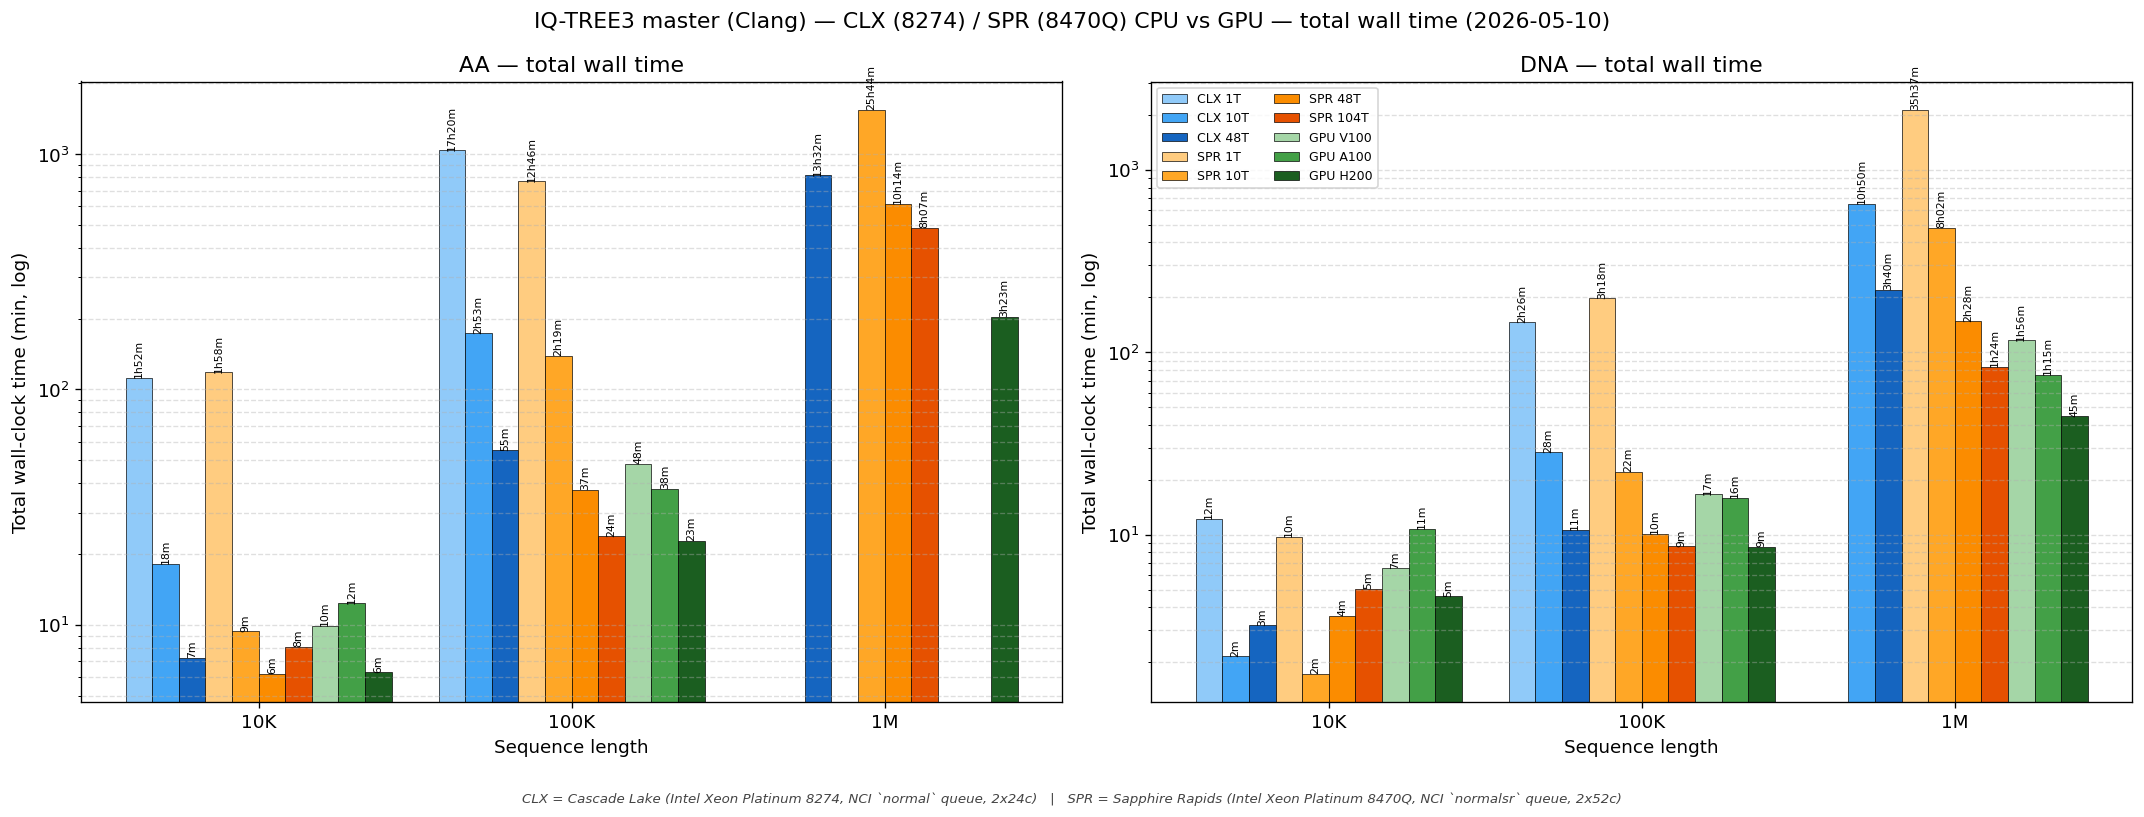

In [3]:
CONFIG_SPECS = [
    ('CLX 1T',     'CLANG_MASTER',    1,   '#90CAF9'),
    ('CLX 10T',    'CLANG_MASTER',    10,  '#42A5F5'),
    ('CLX 48T',    'CLANG_MASTER',    48,  '#1565C0'),
    ('SPR 1T',  'NORMALSR_MASTER', 1,   '#FFCC80'),
    ('SPR 10T', 'NORMALSR_MASTER', 10,  '#FFA726'),
    ('SPR 48T', 'NORMALSR_MASTER', 48,  '#FB8C00'),
    ('SPR 104T','NORMALSR_MASTER', 104, '#E65100'),
    ('GPU V100',     'GPU_V100',        1,   '#A5D6A7'),
    ('GPU A100',     'GPU_A100',        1,   '#43A047'),
    ('GPU H200',     'GPU_H200',        1,   '#1B5E20'),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = df_combined[df_combined['data_type'] == dt]
    n = len(CONFIG_SPECS)
    x = np.arange(len(LENGTHS))
    width = 0.85 / n
    for i, (label, sysname, threads, color) in enumerate(CONFIG_SPECS):
        vals = []
        for length in LENGTHS:
            r = sub[(sub['system'] == sysname) & (sub['threads'] == threads) & (sub['length'] == length)]
            vals.append(r['wall_total_min'].iloc[0] if len(r) and pd.notna(r['wall_total_min'].iloc[0]) else np.nan)
        offsets = x + (i - n/2 + 0.5) * width
        ax.bar(offsets, vals, width, label=label, color=color, edgecolor='black', linewidth=0.4)
        for bx, by in zip(offsets, vals):
            if not np.isnan(by):
                ax.text(bx, by, fmt_time(by), ha='center', va='bottom', fontsize=6.5, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels([LENGTH_LABEL[l] for l in LENGTHS])
    ax.set_yscale('log')
    ax.set_xlabel('Sequence length')
    ax.set_ylabel('Total wall-clock time (min, log)')
    ax.set_title(f'{dt} — total wall time')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, which='both')
axes[1].legend(loc='upper left', fontsize=7.5, ncol=2)
fig.suptitle('IQ-TREE3 master (Clang) — CLX (8274) / SPR (8470Q) CPU vs GPU — total wall time (2026-05-10)')
fig.tight_layout()
add_footnote(fig)
fig.savefig(os.path.join(OUT_DIR, 'fig06_cpu_vs_gpu_wall.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Speedup of every config vs CLANG 1T baseline

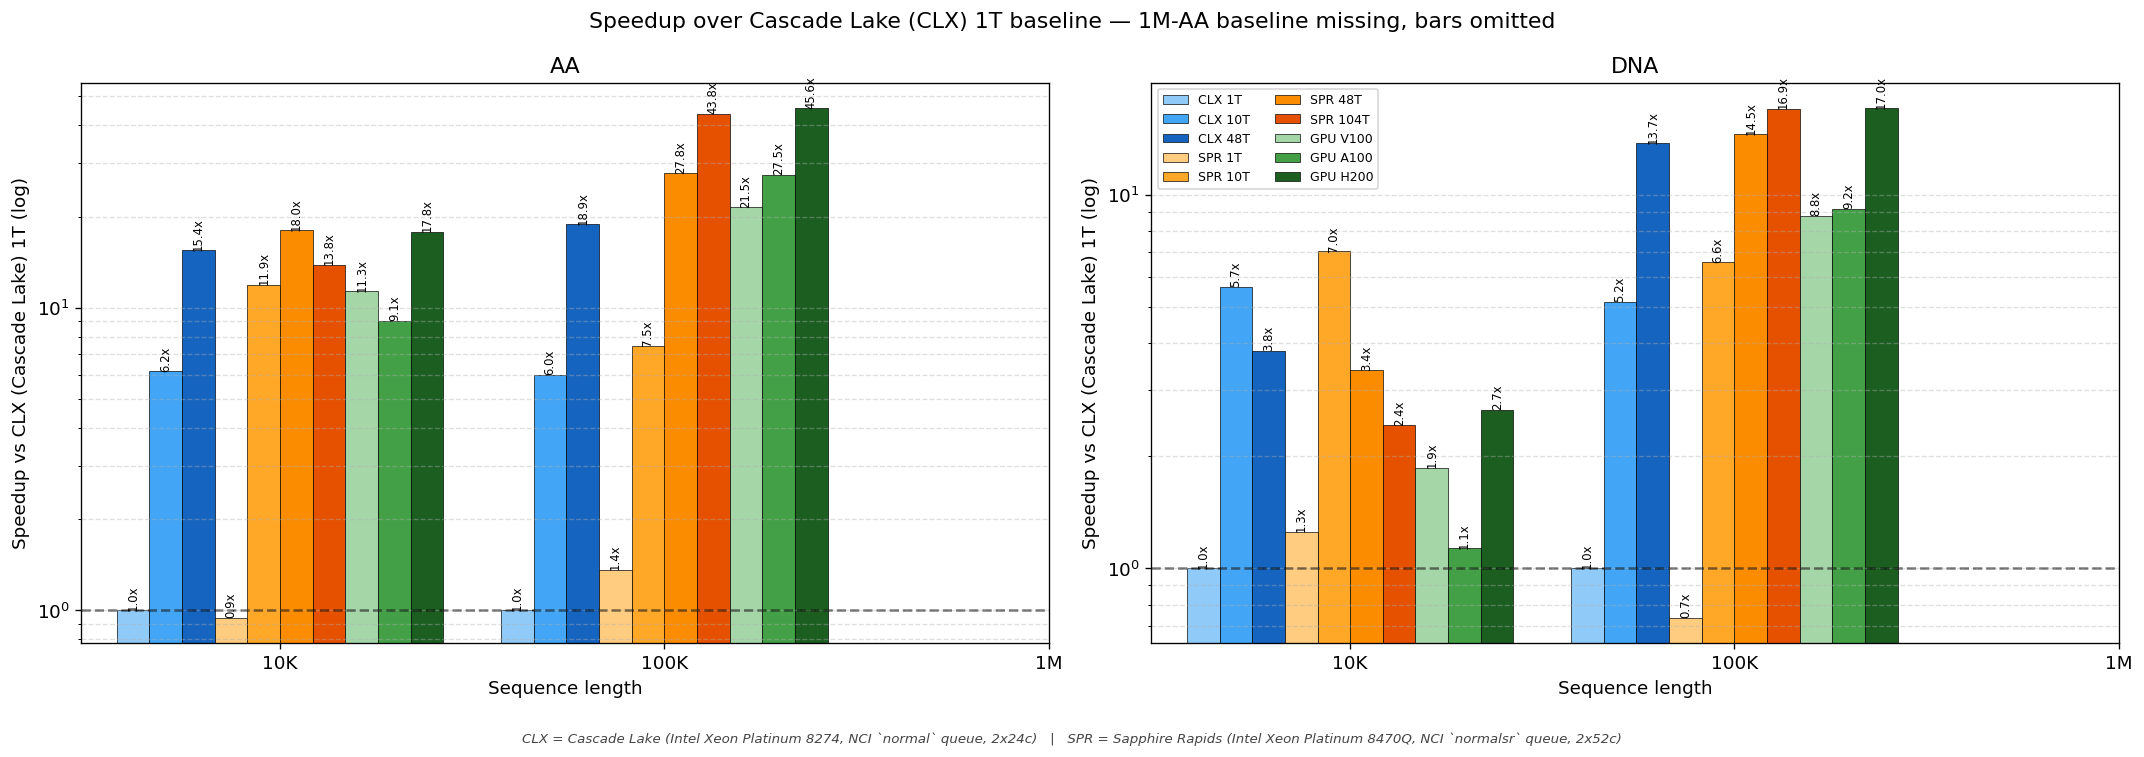

config                  CLX 10T  CLX 1T  CLX 48T  GPU A100  GPU H200  \
data_type length_label                                                 
AA        100K             6.00     1.0    18.89     27.46     45.63   
          10K              6.15     1.0    15.45      9.05     17.81   
DNA       100K             5.16     1.0    13.73      9.16     17.02   
          10K              5.67     1.0     3.82      1.13      2.66   

config                  GPU V100  SPR 104T  SPR 10T  SPR 1T  SPR 48T  
data_type length_label                                                
AA        100K             21.47     43.80     7.47    1.36    27.77  
          10K              11.31     13.85    11.90    0.94    18.03  
DNA       100K              8.78     16.94     6.60    0.74    14.49  
          10K               1.86      2.41     7.05    1.25     3.39

In [4]:
rows = []
for dt in ['AA', 'DNA']:
    for length in LENGTHS:
        base = df_combined[(df_combined['data_type'] == dt) & (df_combined['length'] == length) &
                           (df_combined['system'] == 'CLANG_MASTER') & (df_combined['threads'] == 1)]
        if not len(base) or pd.isna(base['wall_total_sec'].iloc[0]):
            continue
        b = base['wall_total_sec'].iloc[0]
        for label, sysname, threads, _ in CONFIG_SPECS:
            r = df_combined[(df_combined['data_type'] == dt) & (df_combined['length'] == length) &
                            (df_combined['system'] == sysname) & (df_combined['threads'] == threads)]
            if not len(r) or pd.isna(r['wall_total_sec'].iloc[0]):
                continue
            rows.append({
                'data_type': dt, 'length': length, 'length_label': LENGTH_LABEL[length],
                'config': label, 'wall_sec': r['wall_total_sec'].iloc[0],
                'speedup_vs_clx1t': b / r['wall_total_sec'].iloc[0],
            })
df_sp = pd.DataFrame(rows)
df_sp.to_csv(os.path.join(OUT_DIR, 'speedup_vs_clx_1t.csv'), index=False)

label_order = [c[0] for c in CONFIG_SPECS]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = df_sp[df_sp['data_type'] == dt]
    n = len(label_order)
    x = np.arange(len(LENGTHS))
    width = 0.85 / n
    for i, label in enumerate(label_order):
        color = dict((c[0], c[3]) for c in CONFIG_SPECS)[label]
        vals = []
        for length in LENGTHS:
            r = sub[(sub['config'] == label) & (sub['length'] == length)]
            vals.append(r['speedup_vs_clx1t'].iloc[0] if len(r) else np.nan)
        offsets = x + (i - n/2 + 0.5) * width
        ax.bar(offsets, vals, width, label=label, color=color, edgecolor='black', linewidth=0.4)
        for bx, by in zip(offsets, vals):
            if not np.isnan(by):
                ax.text(bx, by, f'{by:.1f}x', ha='center', va='bottom', fontsize=7, rotation=90)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([LENGTH_LABEL[l] for l in LENGTHS])
    ax.set_yscale('log')
    ax.set_xlabel('Sequence length')
    ax.set_ylabel('Speedup vs CLX (Cascade Lake) 1T (log)')
    ax.set_title(f'{dt}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, which='both')
axes[1].legend(loc='upper left', fontsize=7.5, ncol=2)
fig.suptitle('Speedup over Cascade Lake (CLX) 1T baseline — 1M-AA baseline missing, bars omitted')
fig.tight_layout()
add_footnote(fig)
fig.savefig(os.path.join(OUT_DIR, 'fig07_speedup_vs_clx1t.png'), dpi=150, bbox_inches='tight')
plt.show()
df_sp.pivot_table(index=['data_type','length_label'], columns='config', values='speedup_vs_clx1t').round(2)

## 4. GPU vs best CPU per (data_type, length)
Best CPU = the lowest wall-time across all CPU configurations.

In [5]:
rows = []
for dt in ['AA', 'DNA']:
    for length in LENGTHS:
        cpu = df_combined[(df_combined['data_type'] == dt) & (df_combined['length'] == length) &
                          (df_combined['kind'] == 'CPU') & df_combined['wall_total_sec'].notna()]
        if not len(cpu):
            continue
        best_cpu = cpu.loc[cpu['wall_total_sec'].idxmin()]
        for gpu_name in ['GPU_V100', 'GPU_A100', 'GPU_H200']:
            g = df_combined[(df_combined['data_type'] == dt) & (df_combined['length'] == length) &
                            (df_combined['system'] == gpu_name)]
            if not len(g) or pd.isna(g['wall_total_sec'].iloc[0]):
                continue
            gw = g['wall_total_sec'].iloc[0]
            rows.append({
                'data_type': dt, 'length': length, 'length_label': LENGTH_LABEL[length],
                'gpu': gpu_name.replace('GPU_', ''),
                'gpu_wall_sec': gw, 'gpu_wall_min': gw/60,
                'best_cpu_config': f"{ {'CLANG_MASTER':'CLX','NORMALSR_MASTER':'SPR'}.get(best_cpu['system'], best_cpu['system']) } {int(best_cpu['threads'])}T",
                'best_cpu_wall_sec': best_cpu['wall_total_sec'],
                'best_cpu_wall_min': best_cpu['wall_total_sec']/60,
                'gpu_speedup_over_best_cpu': best_cpu['wall_total_sec'] / gw,
            })
df_gvc = pd.DataFrame(rows)
df_gvc.to_csv(os.path.join(OUT_DIR, 'gpu_vs_best_cpu.csv'), index=False)
df_gvc

,data_type,length,length_label,gpu,gpu_wall_sec,gpu_wall_min,best_cpu_config,best_cpu_wall_sec,best_cpu_wall_min,gpu_speedup_over_best_cpu
0,AA,10000,10K,V100,593.847,9.897450,SPR 48T,372.432,6.207200,0.627151
1,AA,10000,10K,A100,741.859,12.364317,SPR 48T,372.432,6.207200,0.502025
2,AA,10000,10K,H200,377.020,6.283667,SPR 48T,372.432,6.207200,0.987831
3,AA,100000,100K,V100,2905.543,48.425717,SPR 104T,1424.306,23.738433,0.490203
4,AA,100000,100K,A100,2272.027,37.867117,SPR 104T,1424.306,23.738433,0.626888
5,AA,100000,100K,H200,1367.078,22.784633,SPR 104T,1424.306,23.738433,1.041862
6,AA,1000000,1M,H200,12197.809,203.296817,SPR 104T,29235.971,487.266183,2.396822
7,DNA,10000,10K,V100,393.366,6.556100,SPR 10T,103.923,1.732050,0.264189
8,DNA,10000,10K,A100,646.964,10.782733,SPR 10T,103.923,1.732050,0.160632
9,DNA,10000,10K,H200,275.252,4.587533,SPR 10T,103.923,1.732050,0.377556


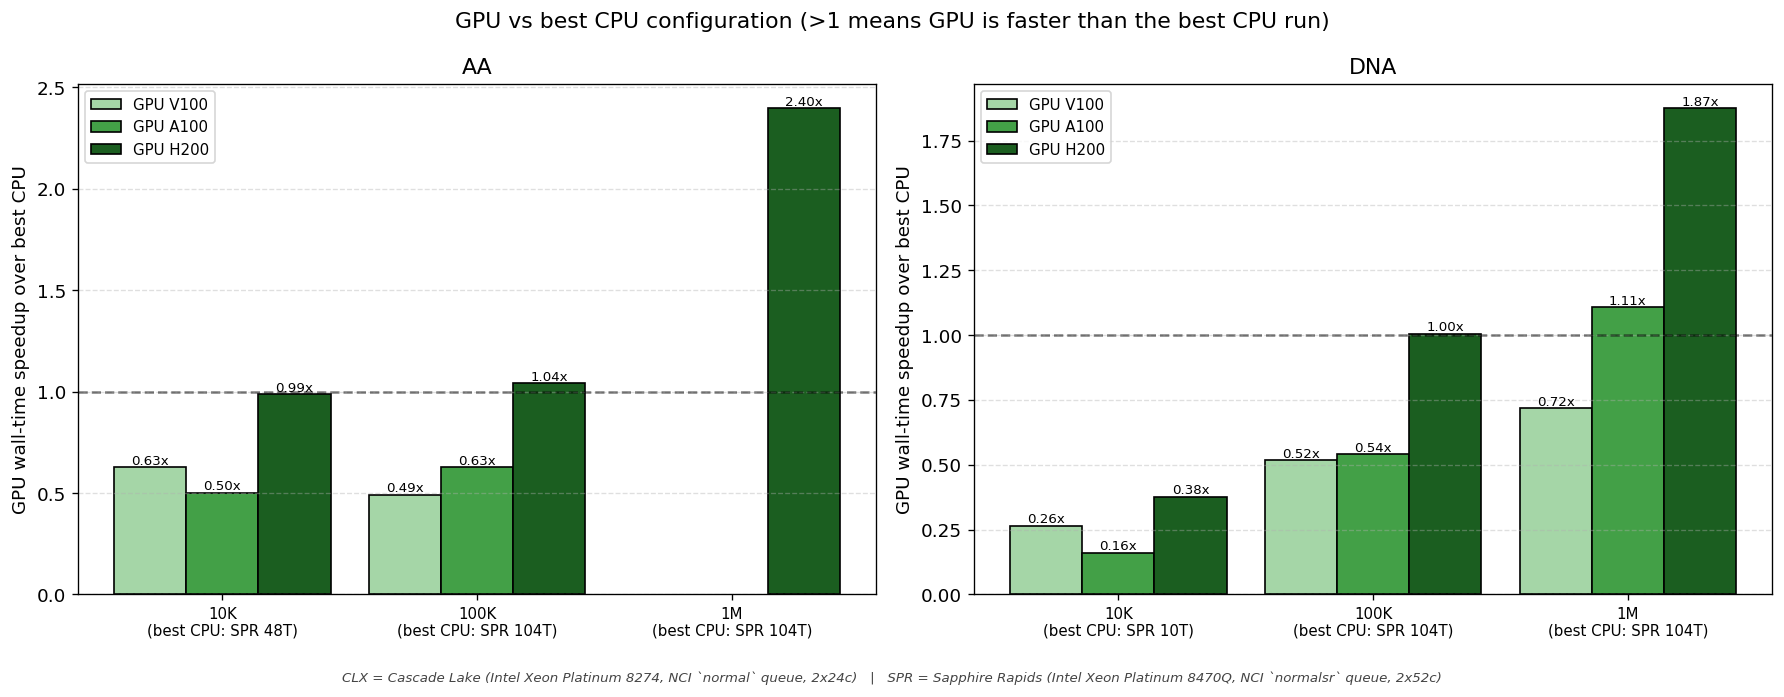

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
gpu_order = ['V100', 'A100', 'H200']
gpu_color = {'V100': '#A5D6A7', 'A100': '#43A047', 'H200': '#1B5E20'}
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = df_gvc[df_gvc['data_type'] == dt]
    n = len(gpu_order)
    x = np.arange(len(LENGTHS))
    width = 0.85 / n
    for i, g in enumerate(gpu_order):
        vals = []
        for length in LENGTHS:
            r = sub[(sub['gpu'] == g) & (sub['length'] == length)]
            vals.append(r['gpu_speedup_over_best_cpu'].iloc[0] if len(r) else np.nan)
        offsets = x + (i - n/2 + 0.5) * width
        bars = ax.bar(offsets, vals, width, color=gpu_color[g], edgecolor='black', label=f'GPU {g}')
        for bx, by in zip(offsets, vals):
            if not np.isnan(by):
                ax.text(bx, by, f'{by:.2f}x', ha='center', va='bottom', fontsize=8)
    # Annotate best-CPU under x-axis labels
    cap = []
    for length in LENGTHS:
        r = sub[sub['length'] == length]
        cap.append(f"{LENGTH_LABEL[length]}\n(best CPU: {r['best_cpu_config'].iloc[0]})" if len(r) else LENGTH_LABEL[length])
    ax.set_xticks(x)
    ax.set_xticklabels(cap, fontsize=9)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel('GPU wall-time speedup over best CPU')
    ax.set_title(f'{dt}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)
fig.suptitle('GPU vs best CPU configuration (>1 means GPU is faster than the best CPU run)')
fig.tight_layout()
add_footnote(fig)
fig.savefig(os.path.join(OUT_DIR, 'fig08_gpu_vs_best_cpu.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Tree-search wall-time only (excludes ModelFinder/init)

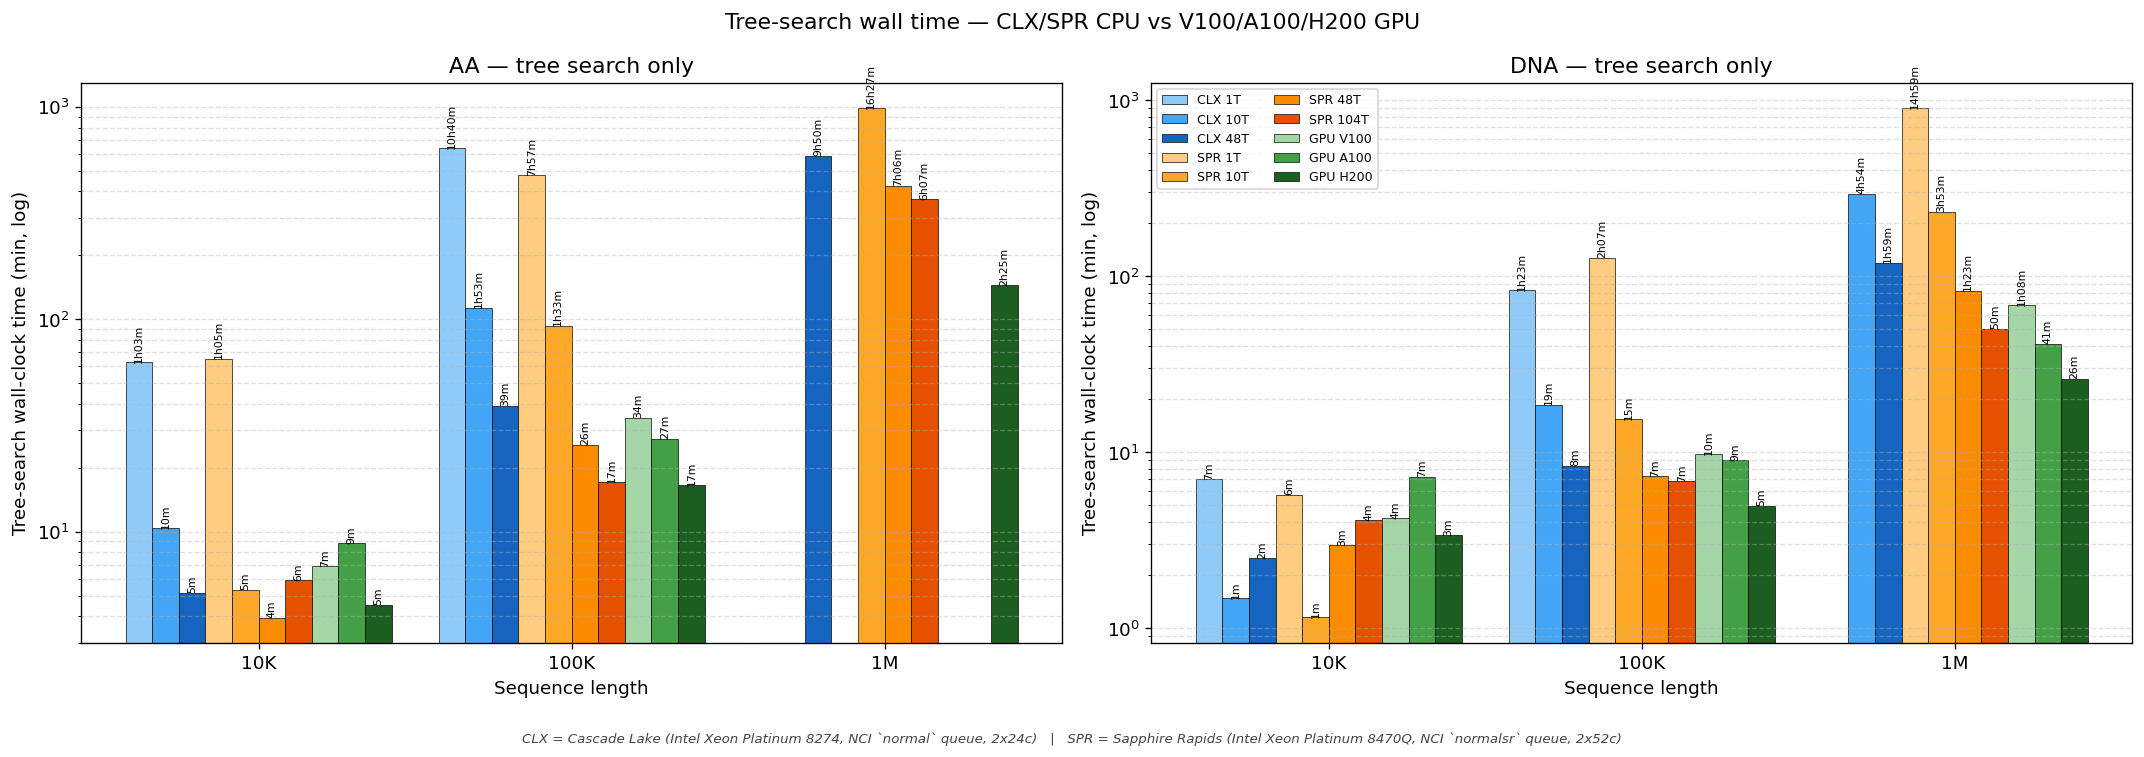

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = df_combined[df_combined['data_type'] == dt]
    n = len(CONFIG_SPECS)
    x = np.arange(len(LENGTHS))
    width = 0.85 / n
    for i, (label, sysname, threads, color) in enumerate(CONFIG_SPECS):
        vals = []
        for length in LENGTHS:
            r = sub[(sub['system'] == sysname) & (sub['threads'] == threads) & (sub['length'] == length)]
            vals.append(r['wall_treesearch_min'].iloc[0] if len(r) and pd.notna(r['wall_treesearch_min'].iloc[0]) else np.nan)
        offsets = x + (i - n/2 + 0.5) * width
        ax.bar(offsets, vals, width, label=label, color=color, edgecolor='black', linewidth=0.4)
        for bx, by in zip(offsets, vals):
            if not np.isnan(by):
                ax.text(bx, by, fmt_time(by), ha='center', va='bottom', fontsize=6.5, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels([LENGTH_LABEL[l] for l in LENGTHS])
    ax.set_yscale('log')
    ax.set_xlabel('Sequence length')
    ax.set_ylabel('Tree-search wall-clock time (min, log)')
    ax.set_title(f'{dt} — tree search only')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, which='both')
axes[1].legend(loc='upper left', fontsize=7.5, ncol=2)
fig.suptitle('Tree-search wall time — CLX/SPR CPU vs V100/A100/H200 GPU')
fig.tight_layout()
add_footnote(fig)
fig.savefig(os.path.join(OUT_DIR, 'fig09_treesearch_cpu_vs_gpu.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Best LnL agreement (CPU master vs GPU)
Reference: CLX (Cascade Lake) 1T best-LnL per (data_type, length). All runs should match within numerical noise.

In [8]:
rows = []
for dt in ['AA', 'DNA']:
    for length in LENGTHS:
        ref = df_combined[(df_combined['data_type']==dt) & (df_combined['length']==length) &
                          (df_combined['system']=='CLANG_MASTER') & (df_combined['threads']==1)]
        if not len(ref) or pd.isna(ref['best_lnl'].iloc[0]):
            ref_lnl = None
        else:
            ref_lnl = ref['best_lnl'].iloc[0]
        for label, sysname, threads, _ in CONFIG_SPECS:
            r = df_combined[(df_combined['data_type']==dt) & (df_combined['length']==length) &
                            (df_combined['system']==sysname) & (df_combined['threads']==threads)]
            if not len(r) or pd.isna(r['best_lnl'].iloc[0]):
                continue
            lnl = r['best_lnl'].iloc[0]
            rows.append({
                'data_type': dt, 'length_label': LENGTH_LABEL[length],
                'config': label, 'best_lnl': lnl,
                'lnl_diff_vs_clang1t': (lnl - ref_lnl) if ref_lnl is not None else None,
            })
df_lnl = pd.DataFrame(rows)
df_lnl.to_csv(os.path.join(OUT_DIR, 'lnl_diff_cpu_vs_gpu.csv'), index=False)
df_lnl.pivot_table(index=['data_type','length_label'], columns='config', values='lnl_diff_vs_clang1t')

config                  CLX 10T  CLX 1T  CLX 48T  GPU A100  GPU H200  \
data_type length_label                                                 
AA        100K              0.0     0.0      0.0     0.002     0.000   
          10K               0.0     0.0      0.0     0.000     0.000   
DNA       100K              0.0     0.0      0.0     0.010     0.012   
          10K               0.0     0.0      0.0     0.001     0.000   

config                  GPU V100  SPR 104T  SPR 10T  SPR 1T  SPR 48T  
data_type length_label                                                
AA        100K              0.00       0.0      0.0     0.0    0.000  
          10K               0.00       0.0      0.0     0.0    0.000  
DNA       100K              0.01       0.0      0.0     0.0    0.000  
          10K               0.00       0.0      0.0     0.0   -0.001

## 7. Summary table

In [9]:
summary = df_combined[df_combined['completed']].copy()
summary['wall_min'] = summary['wall_total_sec'].round(1) / 60
tbl = summary.pivot_table(index=['data_type', 'length_label'],
                          columns='config_label',
                          values='wall_total_min').round(1)
tbl.to_csv(os.path.join(OUT_DIR, 'wall_minutes_pivot.csv'))
tbl

config_label            CLX 10T  CLX 1T  CLX 48T  GPU A100  GPU H200  \
data_type length_label                                                 
AA        100K            173.2  1039.6     55.0      37.9      22.8   
          10K              18.2   111.9      7.2      12.4       6.3   
          1M                NaN     NaN    811.6       NaN     203.3   
DNA       100K             28.4   146.4     10.7      16.0       8.6   
          10K               2.2    12.2      3.2      10.8       4.6   
          1M              650.1     NaN    219.8      75.4      44.6   

config_label            GPU V100  SPR 104T  SPR 10T  SPR 1T  SPR 48T  
data_type length_label                                                
AA        100K              48.4      23.7    139.1   765.6     37.4  
          10K                9.9       8.1      9.4   118.5      6.2  
          1M                 NaN     487.3   1543.5     NaN    613.8  
DNA       100K              16.7       8.6     22.2   198.1     10.1  
          10K                6.6       5.1      1.7     9.7      3.6  
          1M               116.3      83.5    482.0  2137.0    147.5